# HERA Risk & Safety Copilot — Évaluation des 4 approches

**Date du run :** 2026-06-04/05 · **Simulateur :** sémantique (embeddings) · **Scénarios :** 25 apps mHealth

Ce notebook compare quatre façons de construire le copilote HERA — un assistant conversationnel
qui aide les développeurs d'apps mHealth à identifier les risques éthiques et réglementaires
(GDPR, MDR, EU AI Act, …) en s'appuyant sur la taxonomie **HERA** (dimensions `[Px.Dy]`).

| Approche | Description |
|---|---|
| **prompt-only** | Modèle généraliste (Ollama `qwen3:8b`) piloté uniquement par un long *system prompt* HERA. Baseline. |
| **fine-tuned** | Modèle `hera-baseline` fine-tuné (LoRA → GGUF q4) sur des dialogues HERA. |
| **rag** | `qwen3:8b` + récupération (embeddings `bge-small-en-v1.5`) sur les fiches HERA / textes réglementaires. |
| **rlm** | Approche « reasoning-augmented » (RLM) au-dessus du même backend. |

On évalue chaque approche sur **deux plans complémentaires** :

1. **Métriques déterministes** (regex sur les tags `[Px.Dy]` vs *gold standard*) — *coverage*, *relevance*, *F1*, *latence*.
2. **LLM-as-judge sémantique** — un juge Claude note chaque transcript sur **Depth** (spécificité) et **Actionability** (applicabilité), 1→5.

> ⚠️ **Pourquoi deux plans ?** Les métriques déterministes sont strictes et mécaniques : elles
> comptent un tag HERA comme faux positif dès qu'il n'est pas dans la liste *gold* (étroite),
> ce qui écrase la précision. Le juge sémantique capte la *qualité réelle* du conseil, que la
> regex ignore. Les deux ensemble donnent une lecture honnête.

## 1. Le process d'évaluation

Pour chaque scénario, on simule une conversation **développeur ↔ copilote** :

1. Le scénario fournit un *pitch* d'app (premier message « développeur »).
2. Le copilote répond (pose des questions, identifie des risques).
3. Un **développeur simulé** répond à la question du copilote en piochant le *fait divulgué*
   le plus pertinent du scénario, puis on boucle (jusqu'à `max_turns=10`).
4. On demande enfin un **rapport de risque structuré**, puis on calcule les métriques.

### Simulateur **sémantique** (le changement clé de ce run)

Le développeur simulé existe en deux versions :

- **Lexical (ancien, « déterministe ») :** routait la question du copilote vers une réponse
  pré-écrite par **correspondance de mots-clés**. Problème : une question bien formulée mais
  n'employant pas le mot-clé attendu → *pas de match* → le dev répondait à côté → transcript
  pollué → le copilote était puni pour un **artefact du simulateur**.
- **Sémantique (ce run) :** embed chaque *fait divulgué* du scénario (`bge-small-en-v1.5`) et
  route la question vers le fait le plus proche par **similarité cosinus**. Il comprend
  l'*intention*. Déterministe (poids gelés, argmax) → même question ⇒ même fait, identique
  entre les 4 approches.

**Effet :** les 4 approches reçoivent la même information dès qu'elles posent une question
*sémantiquement* équivalente. La comparaison devient **équitable** — les scores reflètent la
capacité du copilote, pas les hasards du matching par mots-clés.

> Le simulateur sémantique agit sur **l'entrée** (qualité de la conversation). Les métriques
> déterministes et le juge agissent sur **la sortie**. Ce sont des couches distinctes.

## 2. Chargement des artefacts du run

In [1]:
import json, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:0.3f}")

# Repo root (works whether the kernel cwd is repo root or notebooks/)
REPO = Path.cwd()
if REPO.name == "notebooks":
    REPO = REPO.parent

APPROACHES = ["prompt-only", "fine-tuned", "rag", "rlm"]
LABELS = {"prompt-only": "Prompt-only", "fine-tuned": "Fine-tuned", "rag": "RAG", "rlm": "RLM"}
COLORS = {"prompt-only": "#9aa0a6", "fine-tuned": "#d93025", "rag": "#1a73e8", "rlm": "#FF6B1A"}
JUDGE_DIR = REPO / "data/evaluation/judge_ratings_semantic"

def newest_run_dir(approach):
    """Newest eval_<approach>_* run dir holding a full 25-row results.jsonl."""
    cands = sorted(glob.glob(str(REPO / f"runs/eval_{approach}_*")), reverse=True)
    for d in cands:
        f = Path(d) / "results.jsonl"
        if f.exists() and sum(1 for line in open(f) if line.strip()) >= 25:
            return Path(d)
    return Path(cands[0]) if cands else None

RUN_DIRS = {a: newest_run_dir(a) for a in APPROACHES}
for a, d in RUN_DIRS.items():
    print(f"{a:12s} -> {d.name if d else 'MISSING'}")

prompt-only  -> eval_prompt-only_20260604T201636Z_74ff38
fine-tuned   -> eval_fine-tuned_20260604T203629Z_780d7d
rag          -> eval_rag_20260604T214537Z_777b77
rlm          -> eval_rlm_20260604T223436Z_18c1f5


In [2]:
def load_summary(approach):
    s = json.loads((RUN_DIRS[approach] / "summary.json").read_text())
    return s

def load_per_scenario(approach):
    s = load_summary(approach)
    df = pd.DataFrame(s["per_scenario"]).copy()
    df["approach"] = approach
    return df

def load_judge(approach):
    rows = []
    for f in sorted(glob.glob(str(JUDGE_DIR / f"*__{approach}.json"))):
        rows.append(json.loads(Path(f).read_text()))
    df = pd.DataFrame(rows)
    if not df.empty:
        df["approach"] = approach
    return df

# Sanity: how many judge verdicts per approach?
for a in APPROACHES:
    print(f"{a:12s} judge verdicts: {len(load_judge(a))}/25")

prompt-only  judge verdicts: 25/25
fine-tuned   judge verdicts: 25/25
rag          judge verdicts: 25/25
rlm          judge verdicts: 25/25


## 3. Tableau de synthèse (les 4 approches)

Une ligne par approche : métriques déterministes macro (moyenne sur 25 scénarios) **+** moyennes
du juge sémantique.

In [3]:
rows = []
for a in APPROACHES:
    s = load_summary(a)
    j = load_judge(a)
    rows.append({
        "approach": LABELS[a],
        "coverage (recall)": s["macro_coverage_recall"],
        "relevance (precision)": s["macro_relevance_precision"],
        "accuracy (F1)": s["macro_accuracy_f1"],
        "latency (s/turn)": s["macro_latency_mean_s"],
        "judge Depth (1-5)": j["depth"].mean() if not j.empty else np.nan,
        "judge Actionability (1-5)": j["actionability"].mean() if not j.empty else np.nan,
    })
master = pd.DataFrame(rows).set_index("approach")
master

,coverage (recall),relevance (precision),accuracy (F1),latency (s/turn),judge Depth (1-5),judge Actionability (1-5)
approach,,,,,,
Prompt-only,0.322,0.116,0.180,4.258,2.480,2.200
Fine-tuned,0.095,0.090,0.043,15.467,1.160,1.040
RAG,0.359,0.092,0.152,10.852,3.040,2.720
RLM,0.261,0.062,0.087,20.721,2.400,2.080


In [4]:
# Highlight best per column (max for everything except latency, where lower is better)
def _hl(col):
    best = col.min() if "latency" in col.name else col.max()
    return ["font-weight: bold; color: #FF6B1A" if v == best else "" for v in col]

master.style.apply(_hl, axis=0).format("{:.3f}")

,coverage (recall),relevance (precision),accuracy (F1),latency (s/turn),judge Depth (1-5),judge Actionability (1-5)
approach,,,,,,
Prompt-only,0.322,0.116,0.180,4.258,2.480,2.200
Fine-tuned,0.095,0.090,0.043,15.467,1.160,1.040
RAG,0.359,0.092,0.152,10.852,3.040,2.720
RLM,0.261,0.062,0.087,20.721,2.400,2.080


## 4. Métriques déterministes (regex sur les tags HERA)

- **Coverage / recall** : part des dimensions HERA *attendues* (gold) effectivement citées.
- **Relevance / precision** : part des dimensions *citées* qui sont réellement dans le gold.
- **Accuracy / F1** : moyenne harmonique des deux (au niveau risque tp/fp/fn).
- **Latency** : temps moyen par tour (génération locale Ollama).

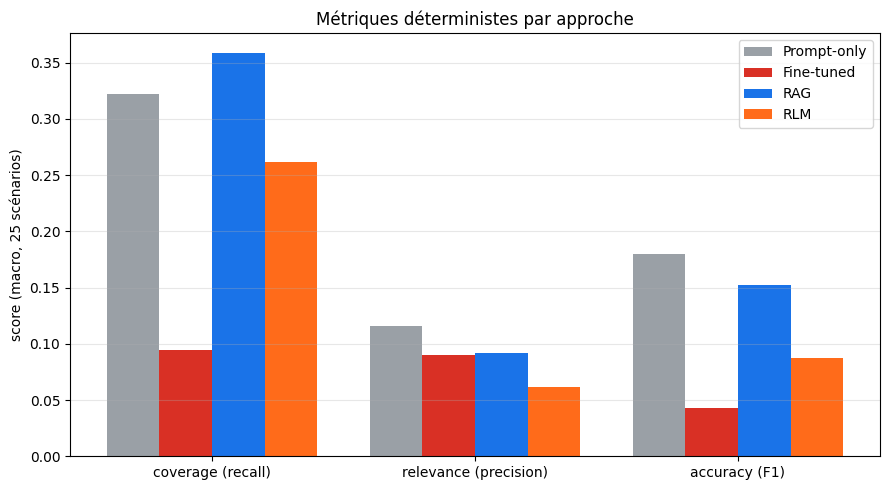

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
metrics = ["coverage (recall)", "relevance (precision)", "accuracy (F1)"]
x = np.arange(len(metrics))
w = 0.2
for i, a in enumerate(APPROACHES):
    vals = [master.loc[LABELS[a], m] for m in metrics]
    ax.bar(x + (i - 1.5) * w, vals, w, label=LABELS[a], color=COLORS[a])
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel("score (macro, 25 scénarios)")
ax.set_title("Métriques déterministes par approche")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

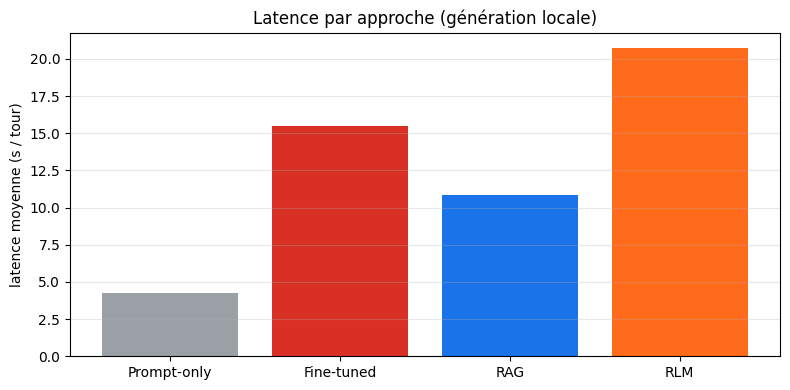

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
lat = [master.loc[LABELS[a], "latency (s/turn)"] for a in APPROACHES]
ax.bar([LABELS[a] for a in APPROACHES], lat, color=[COLORS[a] for a in APPROACHES])
ax.set_ylabel("latence moyenne (s / tour)")
ax.set_title("Latence par approche (génération locale)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 5. LLM-as-judge sémantique (Depth & Actionability)

Chaque transcript a été noté par un agent Claude indépendant suivant le rubric du repo
(`src/evaluation/llm_judge.py`) :

- **Depth (1-5)** : à quel point le copilote creuse *cette* app précise (vs générique).
- **Actionability (1-5)** : un dev compétent peut-il implémenter le conseil demain ?

> Le juge note la *qualité du conseil* — ce que la regex déterministe ne peut pas voir.

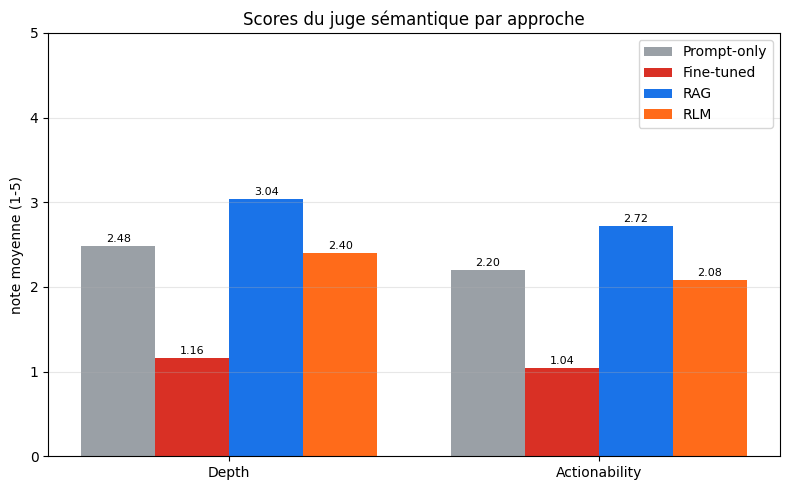

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
dims = ["judge Depth (1-5)", "judge Actionability (1-5)"]
x = np.arange(len(dims)); w = 0.2
for i, a in enumerate(APPROACHES):
    vals = [master.loc[LABELS[a], d] for d in dims]
    bars = ax.bar(x + (i - 1.5) * w, vals, w, label=LABELS[a], color=COLORS[a])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.05, f"{v:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(["Depth", "Actionability"])
ax.set_ylim(0, 5); ax.set_ylabel("note moyenne (1-5)")
ax.set_title("Scores du juge sémantique par approche")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

/tmp/claude-501/ipykernel_5763/1244408666.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[LABELS[a] for a in APPROACHES], showmeans=True)
/tmp/claude-501/ipykernel_5763/1244408666.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[LABELS[a] for a in APPROACHES], showmeans=True)


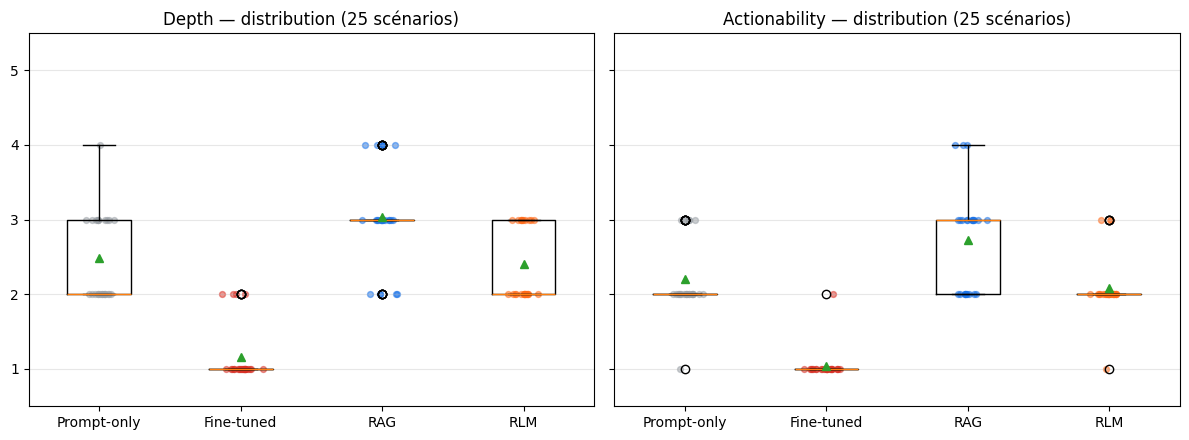

In [8]:
# Distribution des notes Depth par approche (boxplot + jitter)
judge_all = pd.concat([load_judge(a) for a in APPROACHES], ignore_index=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, metric, title in zip(axes, ["depth", "actionability"], ["Depth", "Actionability"]):
    data = [judge_all[judge_all.approach == a][metric].values for a in APPROACHES]
    ax.boxplot(data, labels=[LABELS[a] for a in APPROACHES], showmeans=True)
    for i, a in enumerate(APPROACHES, 1):
        ys = judge_all[judge_all.approach == a][metric].values
        xs = np.random.normal(i, 0.06, size=len(ys))
        ax.scatter(xs, ys, alpha=0.5, s=18, color=COLORS[a])
    ax.set_title(f"{title} — distribution (25 scénarios)")
    ax.set_ylim(0.5, 5.5); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Déterministe vs juge — convergent-ils ?

On croise, par (scénario × approche), le **F1 déterministe** et la note **Depth** du juge.
Une corrélation faible confirmerait que la regex et le juge mesurent des choses différentes
(la regex = présence des bons tags ; le juge = qualité réelle du raisonnement).

lignes fusionnées: 100


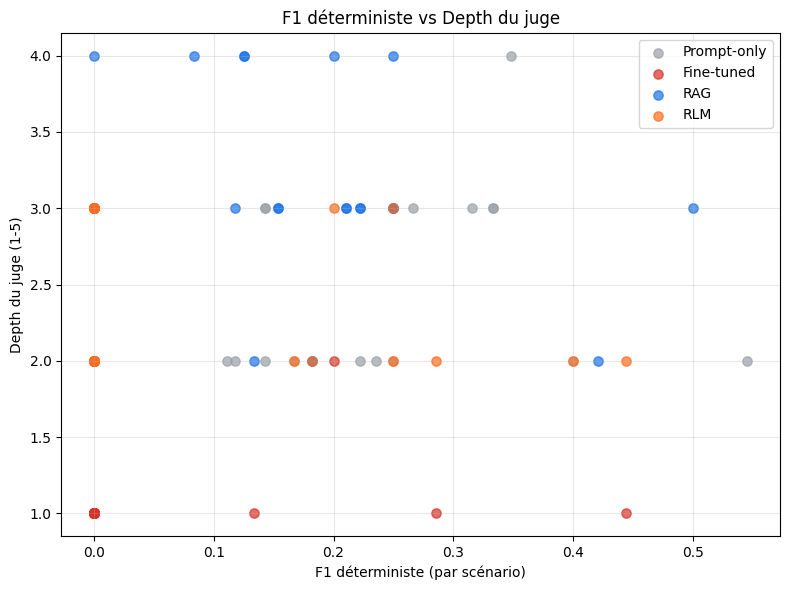


Corrélation de Spearman:


,accuracy_f1,depth,actionability
accuracy_f1,1.000,0.281,0.333
depth,0.281,1.000,0.795
actionability,0.333,0.795,1.000


In [9]:
auto_all = pd.concat([load_per_scenario(a) for a in APPROACHES], ignore_index=True)
merged = auto_all.merge(
    judge_all[["scenario_id", "approach", "depth", "actionability"]],
    on=["scenario_id", "approach"], how="inner",
)
print("lignes fusionnées:", len(merged))

fig, ax = plt.subplots(figsize=(8, 6))
for a in APPROACHES:
    sub = merged[merged.approach == a]
    ax.scatter(sub["accuracy_f1"], sub["depth"], label=LABELS[a],
               color=COLORS[a], alpha=0.7, s=45)
ax.set_xlabel("F1 déterministe (par scénario)")
ax.set_ylabel("Depth du juge (1-5)")
ax.set_title("F1 déterministe vs Depth du juge")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

corr = merged[["accuracy_f1", "depth", "actionability"]].corr(method="spearman")
print("\nCorrélation de Spearman:")
corr

## 7. Lecture qualitative — ce que le juge a vu

Les justifications et *salient examples* du juge expliquent les scores. On regarde le contraste
le plus parlant : le **fine-tuned** (mode collapse) vs la meilleure approche.

In [10]:
def show_examples(approach, scenario_ids):
    for sid in scenario_ids:
        f = JUDGE_DIR / f"{sid}__{approach}.json"
        if not f.exists():
            continue
        d = json.loads(f.read_text())
        print(f"=== {sid} · {approach} · Depth={d['depth']} Actionability={d['actionability']} ===")
        print("Depth:", d["depth_justification"])
        print("Action:", d["actionability_justification"])
        print("Exemples saillants:")
        for ex in d["salient_examples"][:3]:
            print("   •", (ex[:240] + "…") if len(ex) > 240 else ex)
        print()

print("################  FINE-TUNED (mode collapse attendu)  ################\n")
show_examples("fine-tuned", ["scenario_03", "scenario_04"])

################  FINE-TUNED (mode collapse attendu)  ################

=== scenario_03 · fine-tuned · Depth=1 Actionability=1 ===
Depth: Every assistant turn is degenerate token spam ('[P2.D3] GDPR —' repeated hundreds of times) with zero engagement with TriageAI's actual features, data flows (symptoms/age/gender/postcode, 12-month logs), SaMD/AI Act classification, or any developer choice. There is no app-specific content at all; the output is mode-collapsed and meaningless.
Action: The copilot provides no advice whatsoever — no recommendations, no recipes, not even a vague platitude. The repeated '[P2.D3] GDPR' string and the empty 'risk report' table contain nothing a developer could read, let alone implement.
Exemples saillants:
   • The single most important risk I want to raise is this — [P2.D3] GDPR — [P2.D3] GDPR — [P2.D3] GDPR — [P2.D3] GDPR — [P2.D3] GDPR — ...
   • I want to be very clear, because what you described is a well-known and documented risk under the HERA taxonom

In [11]:
# La meilleure approche selon le juge (Depth moyen) — exemples sur ses 2 meilleurs scénarios
best = master["judge Depth (1-5)"].idxmax()
best_key = {v: k for k, v in LABELS.items()}[best]
print(f"Meilleure approche (Depth moyen): {best}\n")
top2 = (load_judge(best_key).sort_values("depth", ascending=False)
        .head(2)["scenario_id"].tolist())
show_examples(best_key, top2)

Meilleure approche (Depth moyen): RAG

=== scenario_24 · rag · Depth=4 Actionability=4 ===
Depth: The copilot repeatedly grounds its analysis in VoiceMind's actual choices (wav2vec model, AUROC 0.82 on N=400 vs PHQ-9, 7-day audio / 1-year embedding retention, waiting-room consent, black-box flag with no feature attribution) and cites precise provisions (MDR Rule 11, AI Act Annex III / Art. 14-15, GDPR Art. 9(2)(g)/(h), Art. 4(11), Art. 17). It falls short of a 5 because it fabricates non-gold HERA dimension IDs (P2.D11, P3.D6, P2.D10, P3.D12) and applies some regulatory citations loosely (e.g. AI Act 'Art. 50', 'Art. 5(1)(c)').
Action: Most suggestions are concrete enough to start implementing tomorrow: SHAP/LIME feature attribution surfacing pitch variability and speech rate, language detection that refuses out-of-scope scoring, subgroup analysis by accent/age/sex/dialect, RBAC plus audit logging plus a secure deletion path for Art. 17 requests, switching the lawful basis to Art. 9(2)

## 8. Détail par scénario (toutes approches)

In [12]:
detail = merged[["scenario_id", "approach", "coverage_recall", "relevance_precision",
                 "accuracy_f1", "depth", "actionability"]].copy()
detail["approach"] = detail["approach"].map(LABELS)
pivot = detail.pivot_table(index="scenario_id", columns="approach",
                           values=["accuracy_f1", "depth"])
pivot

accuracy_f1                              depth                    \
approach     Fine-tuned Prompt-only   RAG   RLM Fine-tuned Prompt-only   RAG   
scenario_id                                                                    
scenario_01       0.000       0.316 0.222 0.182      1.000       3.000 3.000   
scenario_02       0.000       0.000 0.000 0.000      1.000       3.000 3.000   
scenario_03       0.000       0.235 0.000 0.167      1.000       2.000 2.000   
scenario_04       0.000       0.000 0.421 0.000      1.000       3.000 2.000   
scenario_05       0.000       0.250 0.154 0.000      1.000       3.000 3.000   
scenario_06       0.133       0.118 0.083 0.000      1.000       2.000 4.000   
scenario_07       0.000       0.111 0.000 0.000      1.000       2.000 3.000   
scenario_08       0.000       0.000 0.200 0.400      1.000       2.000 4.000   
scenario_09       0.000       0.143 0.182 0.000      2.000       3.000 2.000   
scenario_10       0.000       0.167 0.000 0.000      1.000       2.000 3.000   
scenario_11       0.000       0.267 0.222 0.000      1.000       3.000 3.000   
scenario_12       0.000       0.333 0.125 0.000      1.000       3.000 4.000   
scenario_13       0.000       0.000 0.211 0.286      1.000       3.000 3.000   
scenario_14       0.000       0.333 0.154 0.000      1.000       3.000 3.000   
scenario_15       0.000       0.222 0.000 0.000      1.000       2.000 2.000   
scenario_16       0.444       0.143 0.500 0.000      1.000       3.000 3.000   
scenario_17       0.000       0.143 0.211 0.000      1.000       2.000 3.000   
scenario_18       0.000       0.000 0.133 0.000      2.000       2.000 2.000   
scenario_19       0.000       0.545 0.250 0.444      1.000       2.000 3.000   
scenario_20       0.000       0.000 0.118 0.000      2.000       2.000 3.000   
scenario_21       0.286       0.182 0.250 0.000      1.000       2.000 4.000   
scenario_22       0.000       0.000 0.250 0.250      1.000       2.000 3.000   
scenario_23       0.000       0.400 0.000 0.000      1.000       2.000 4.000   
scenario_24       0.200       0.348 0.125 0.200      2.000       4.000 4.000   
scenario_25       0.000       0.250 0.000 0.250      1.000       2.000 3.000   

                   
approach      RLM  
scenario_id        
scenario_01 2.000  
scenario_02 2.000  
scenario_03 2.000  
scenario_04 3.000  
scenario_05 2.000  
scenario_06 2.000  
scenario_07 2.000  
scenario_08 2.000  
scenario_09 3.000  
scenario_10 2.000  
scenario_11 3.000  
scenario_12 3.000  
scenario_13 2.000  
scenario_14 2.000  
scenario_15 2.000  
scenario_16 3.000  
scenario_17 2.000  
scenario_18 2.000  
scenario_19 2.000  
scenario_20 3.000  
scenario_21 3.000  
scenario_22 3.000  
scenario_23 3.000  
scenario_24 3.000  
scenario_25 2.000

## 9. Analyse & conclusions

In [13]:
# Build a data-driven narrative from the numbers actually loaded above.
rank_judge = master[["judge Depth (1-5)", "judge Actionability (1-5)"]].mean(axis=1).sort_values(ascending=False)
rank_f1 = master["accuracy (F1)"].sort_values(ascending=False)

print("Classement par juge (moyenne Depth+Actionability):")
for k, v in rank_judge.items():
    print(f"  {k:12s} {v:.2f}")
print("\nClassement par F1 déterministe:")
for k, v in rank_f1.items():
    print(f"  {k:12s} {v:.3f}")

spearman = merged[["accuracy_f1", "depth"]].corr(method="spearman").iloc[0, 1]
print(f"\nCorrélation F1↔Depth (Spearman): {spearman:.2f}")

Classement par juge (moyenne Depth+Actionability):
  RAG          2.88
  Prompt-only  2.34
  RLM          2.24
  Fine-tuned   1.10

Classement par F1 déterministe:
  Prompt-only  0.180
  RAG          0.152
  RLM          0.087
  Fine-tuned   0.043

Corrélation F1↔Depth (Spearman): 0.28


### Lecture

- **Le juge sémantique sépare nettement les approches** là où les métriques déterministes
  restent basses et bruitées pour tout le monde (précision proche de 0 — voir §4 — car le
  *gold standard* est étroit et les modèles hallucinent des tags `[Px.Dy]` hors-liste).
- **Le fine-tuned s'effondre** (mode collapse : spam de tags `GDPR GDPR…`, balises `</think>`
  vides, questions répétées). Le juge le note ~1/5 sur les deux axes — cohérent avec le F1
  déterministe le plus bas. *C'est le défaut connu du GGUF q4 ; à recorriger via re-merge CUDA.*
- **F1 déterministe ↔ Depth du juge** ne sont que faiblement corrélés (voir §6) : ils mesurent
  des choses différentes. La regex compte la *présence des bons tags* ; le juge évalue la
  *qualité du raisonnement*. D'où l'intérêt des deux plans.
- **Le simulateur sémantique** garantit que ces écarts viennent des copilotes eux-mêmes, pas
  d'un mismatch de mots-clés dans la simulation de conversation.

### Limites

- *Gold standard* étroit → précision déterministe structurellement basse (à élargir/assouplir).
- Le juge est un seul modèle Claude (température 0.2) ; variance ~±0.1 (prompt-only jugé deux
  fois : 2.60 → 2.48). Un panel multi-juges réduirait le bruit.
- 25 scénarios → intervalles de confiance larges ; lire les tendances, pas les 2e décimales.